# **1. 생물학적 뉴런**
생물학적 뉴런은 신경계를 구성하는 기본 단위로, 정보를 수집, 처리, 전달하는 기능을 담당합니다. 뉴런은 크게 세 가지 주요 부분으로 나뉩니다: 수상돌기(dendrite), 세포체(cell body), 축삭(axon)입니다. 수상돌기는 다른 뉴런이나 외부 자극으로부터 신호를 받아들이는 역할을 하며, 세포체는 이 신호를 처리하고 통합합니다. 처리된 신호는 축삭을 통해 다음 뉴런이나 근육, 혹은 샘과 같은 다른 조직으로 전달됩니다. 축삭의 끝에는 시냅스(synapse)가 있어 화학적 신호 또는 전기적 신호를 통해 다른 세포와 연결됩니다. 뉴런은 이러한 작용을 통해 신경계가 복잡한 정보를 효율적으로 처리하고 전달할 수 있도록 돕습니다.

![뉴런](./images/뉴런.png)

# **2. 인공 신경망**
인공 신경망(Artificial Neural Network, ANN)은 생물학적 신경망의 구조와 기능을 모방한 계산 모델로, 여러 개의 인공 뉴런을 계층적으로 연결하여 구성됩니다. 기본적으로 입력층(input layer), 은닉층(hidden layer), 출력층(output layer)으로 이루어지며, 각 층의 뉴런들은 다음 층의 뉴런과 연결되어 데이터를 전달하고 처리합니다. 입력 데이터는 가중치와 활성화 함수 등의 연산을 거쳐 점차 복잡한 특징을 추출하며, 최종적으로 출력층에서 예측값이나 결과를 생성합니다. 신경망은 데이터에 기반한 학습을 통해 가중치를 조정하면서 문제를 해결하도록 최적화됩니다. 이러한 특성 덕분에 이미지 분류, 음성 인식, 자연어 처리 등 다양한 분야에서 뛰어난 성능을 발휘하며, 딥러닝의 주요 구성 요소로 활용됩니다. ANN은 다층 구조와 비선형 활성화 함수를 통해 복잡한 데이터 간의 관계를 학습할 수 있는 강력한 도구입니다.

# **3. 인공 신경망의 역사**
1940년대 ~ 1980년대
인공 신경망(Artificial Neural Network, ANN)의 역사는 1940년대에 시작된 초기 개념부터 현대의 딥러닝에 이르기까지 긴 발전 과정을 거쳤습니다. 1943년, 워런 맥컬록(Warren McCulloch)과 월터 피츠(Walter Pitts)는 생물학적 뉴런을 수학적으로 모델링한 맥컬록-피츠 뉴런을 제안하며 ANN의 기초를 마련했습니다. 1958년, 프랭크 로젠블렛(Frank Rosenblatt)은 단층 퍼셉트론(perceptron)을 개발하여 ANN이 학습과 분류 문제를 해결할 수 있음을 보여주었습니다. 그러나 1969년, 마빈 민스키(Marvin Minsky)와 시모어 페이퍼트(Seymour Papert)는 퍼셉트론의 한계를 지적하며, 비선형 문제를 해결하지 못한다는 사실을 제시하였고, 이는 ANN 연구의 침체기로 이어졌습니다.

### 퍼셉트론
퍼셉트론(Perceptron)은 1958년 프랭크 로젠블렛(Frank Rosenblatt)이 제안한 인공 뉴런 모델로, 가장 간단한 형태의 인공 신경망입니다. 퍼셉트론은 입력 값과 해당 가중치(weight)의 곱을 모두 더한 값에 편향(bias)을 더하고, 이를 활성화 함수(보통 계단 함수)로 변환하여 이진 출력(0 또는 1)을 생성합니다. 학습 과정에서는 출력 값이 실제 값과 다를 경우, 가중치를 조정하는 방식으로 학습이 이루어집니다. 퍼셉트론은 단층 구조로 선형적으로 분리 가능한 문제를 해결할 수 있지만, XOR 문제와 같은 비선형적으로 분리되는 문제를 해결하지 못하는 한계가 있습니다.

![단층 퍼셉트론](./images/단층%20퍼셉트론.png)

In [8]:
# 논리 회귀(단층 퍼셉트론)로 AND 문제 풀기

import torch
import torch.nn as nn
import torch.optim as optim

X = torch.FloatTensor([[0, 0], [0, 1], [1, 0], [1, 1]]) # and 문제이니 데이터셋 넣음
y = torch.FloatTensor([[0], [0], [0], [1]])

model = nn.Sequential(
    nn.Linear(2, 1),
    nn.Sigmoid() # 확률 변환
)

optimizer = optim.SGD(model.parameters(), lr=1)

epochs = 1000

for epoch in range(epochs + 1):
    y_pred = model(X)
    loss = nn.BCELoss()(y_pred, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        y_bool = (y_pred >= 0.5).float()
        accuracy = (y == y_bool).float().sum() / len(y) * 100
        print(f'Epoch {epoch:4d}/{epochs} Loss: {loss:.6f} Accuracy: {accuracy:.2f}%')

Epoch    0/1000 Loss: 0.705187 Accuracy: 50.00%
Epoch  100/1000 Loss: 0.140613 Accuracy: 100.00%
Epoch  200/1000 Loss: 0.080590 Accuracy: 100.00%
Epoch  300/1000 Loss: 0.056001 Accuracy: 100.00%
Epoch  400/1000 Loss: 0.042730 Accuracy: 100.00%
Epoch  500/1000 Loss: 0.034468 Accuracy: 100.00%
Epoch  600/1000 Loss: 0.028847 Accuracy: 100.00%
Epoch  700/1000 Loss: 0.024782 Accuracy: 100.00%
Epoch  800/1000 Loss: 0.021710 Accuracy: 100.00%
Epoch  900/1000 Loss: 0.019308 Accuracy: 100.00%
Epoch 1000/1000 Loss: 0.017381 Accuracy: 100.00%


In [9]:
# 논리 회귀(단층 퍼셉트론)로 OR 문제 풀기

X = torch.FloatTensor([[0, 0], [0, 1], [1, 0], [1, 1]])
y = torch.FloatTensor([[0], [1], [1], [1]])

model = nn.Sequential(
    nn.Linear(2, 1),
    nn.Sigmoid()
)

optimizer = optim.SGD(model.parameters(), lr=1)

epochs = 1000

for epoch in range(epochs + 1):
    y_pred = model(X)
    loss = nn.BCELoss()(y_pred, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        y_bool = (y_pred >= 0.5).float()
        accuracy = (y == y_bool).float().sum() / len(y) * 100
        print(f'Epoch {epoch:4d}/{epochs} Loss: {loss:.6f} Accuracy: {accuracy:.2f}%')

Epoch    0/1000 Loss: 0.732777 Accuracy: 50.00%
Epoch  100/1000 Loss: 0.094251 Accuracy: 100.00%
Epoch  200/1000 Loss: 0.048300 Accuracy: 100.00%
Epoch  300/1000 Loss: 0.032073 Accuracy: 100.00%
Epoch  400/1000 Loss: 0.023905 Accuracy: 100.00%
Epoch  500/1000 Loss: 0.019017 Accuracy: 100.00%
Epoch  600/1000 Loss: 0.015772 Accuracy: 100.00%
Epoch  700/1000 Loss: 0.013465 Accuracy: 100.00%
Epoch  800/1000 Loss: 0.011742 Accuracy: 100.00%
Epoch  900/1000 Loss: 0.010408 Accuracy: 100.00%
Epoch 1000/1000 Loss: 0.009344 Accuracy: 100.00%


In [10]:
# 논리 회귀(단층 퍼셉트론)로 XOR 문제 풀기

X = torch.FloatTensor([[0, 0], [0, 1], [1, 0], [1, 1]])
y = torch.FloatTensor([[0], [1], [1], [0]])

model = nn.Sequential(
    nn.Linear(2, 1),
    nn.Sigmoid()
)

optimizer = optim.SGD(model.parameters(), lr=1)

epochs = 1000

for epoch in range(epochs + 1):
    y_pred = model(X)
    loss = nn.BCELoss()(y_pred, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        y_bool = (y_pred >= 0.5).float()
        accuracy = (y == y_bool).float().sum() / len(y) * 100
        print(f'Epoch {epoch:4d}/{epochs} Loss: {loss:.6f} Accuracy: {accuracy:.2f}%')

Epoch    0/1000 Loss: 0.766350 Accuracy: 50.00%
Epoch  100/1000 Loss: 0.693148 Accuracy: 50.00%
Epoch  200/1000 Loss: 0.693147 Accuracy: 25.00%
Epoch  300/1000 Loss: 0.693147 Accuracy: 25.00%
Epoch  400/1000 Loss: 0.693147 Accuracy: 50.00%
Epoch  500/1000 Loss: 0.693147 Accuracy: 50.00%
Epoch  600/1000 Loss: 0.693147 Accuracy: 50.00%
Epoch  700/1000 Loss: 0.693147 Accuracy: 50.00%
Epoch  800/1000 Loss: 0.693147 Accuracy: 50.00%
Epoch  900/1000 Loss: 0.693147 Accuracy: 50.00%
Epoch 1000/1000 Loss: 0.693147 Accuracy: 50.00%


### 1980년대 ~ 2000년대
1980년대에 이르러 역전파(backpropagation) 알고리즘이 재발견되면서 ANN이 다시 주목받기 시작했습니다. 특히 제프리 힌턴(Geoffrey Hinton) 등 연구자들의 공헌으로 다층 퍼셉트론(Multi-Layer Perceptron, MLP)이 비선형 문제를 해결할 수 있음을 보였고, ANN 연구가 활발해졌습니다. 1990년대에는 합성곱 신경망(CNN)과 순환 신경망(RNN) 등 특화된 구조가 개발되며 ANN이 더 복잡한 문제를 다룰 수 있게 되었습니다.

### 다층 퍼셉트론
다층 퍼셉트론(Multi-Layer Perceptron, MLP)은 입력층(Input layer), 하나 이상의 은닉층(Hidden layer), 출력층(Output layer)으로 구성된 인공신경망 구조입니다. 각 층은 여러 개의 뉴런으로 이루어져 있으며, 앞 층의 출력은 다음 층의 입력으로 전달되고, 각 연결에는 가중치가 부여됩니다. 비선형 활성화 함수(ReLU, sigmoid 등)를 사용하여 복잡한 패턴이나 비선형 문제를 학습할 수 있으며, 역전파(Backpropagation) 알고리즘을 통해 오차를 최소화하는 방향으로 가중치를 반복적으로 조정합니다. 이 구조는 이미지 분류, 자연어 처리, 음성 인식 등 다양한 분야에서 널리 사용됩니다.

![다층 퍼셉트론](./images/다층퍼셉트론.png)
![다층 퍼셉트론2](./images/다층퍼셉트론2.png)
![다층 퍼셉트론3](./images/다층퍼셉트론3.png)

### 오차 역전파
오차 역전파(Backpropagation)는 인공신경망이 학습할 때 출력값과 실제값의 차이인 오차를 출력층에서 입력층 방향으로 역전달하여 각 가중치를 수정하는 알고리즘입니다. 이 과정은 먼저 순전파(Forward propagation)를 통해 예측값을 계산하고, 손실 함수(Loss function)를 이용해 오차를 구한 뒤, 체인룰(Chain Rule)을 적용해 각 층의 가중치가 오차에 얼마나 영향을 주었는지를 계산합니다. 이렇게 계산된 그래디언트(기울기)를 기반으로 경사 하강법(Gradient Descent)을 이용해 가중치를 업데이트함으로써, 신경망이 점점 더 정확한 출력을 내도록 학습이 이루어집니다.

![오차 역전파](./images/오차역전파.png)

In [11]:
model = nn.Sequential(
    nn.Linear(2, 2),
    # 은닉층에 비선형성(차원이나 선을 꺾음) 주기 위해
    nn.Sigmoid(), # 비선형 함수로 쓰임. 0~1 사이로 확률값 구하기 위해 쓰는 것 아님
    nn.Linear(2, 1), # 분류 문제 해결을 위해 출력은 1
    # 분류 위해
    nn.Sigmoid() # 분류 문제 해결 위해 0~1로 확률 변환 위해 사용
)

print(model)

Sequential(
  (0): Linear(in_features=2, out_features=2, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=2, out_features=1, bias=True)
  (3): Sigmoid()
)


In [12]:
# 논리 회귀(다층 퍼셉트론)로 XOR 문제 풀기

X = torch.FloatTensor([[0, 0], [0, 1], [1, 0], [1, 1]])
y = torch.FloatTensor([[0], [1], [1], [0]])

optimizer = optim.SGD(model.parameters(), lr=1)

epochs = 1000

for epoch in range(epochs + 1):
    y_pred = model(X)
    loss = nn.BCELoss()(y_pred, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        y_bool = (y_pred >= 0.5).float()
        accuracy = (y == y_bool).float().sum() / len(y) * 100
        print(f'Epoch {epoch:4d}/{epochs} Loss: {loss:.6f} Accuracy: {accuracy:.2f}%')

Epoch    0/1000 Loss: 0.735219 Accuracy: 50.00%
Epoch  100/1000 Loss: 0.693008 Accuracy: 50.00%
Epoch  200/1000 Loss: 0.692806 Accuracy: 50.00%
Epoch  300/1000 Loss: 0.692217 Accuracy: 50.00%
Epoch  400/1000 Loss: 0.689087 Accuracy: 75.00%
Epoch  500/1000 Loss: 0.656707 Accuracy: 75.00%
Epoch  600/1000 Loss: 0.497505 Accuracy: 75.00%
Epoch  700/1000 Loss: 0.163568 Accuracy: 100.00%
Epoch  800/1000 Loss: 0.070154 Accuracy: 100.00%
Epoch  900/1000 Loss: 0.042543 Accuracy: 100.00%
Epoch 1000/1000 Loss: 0.030117 Accuracy: 100.00%


# **4. 비선형 활성화 함수**
비선형 활성화 함수는 신경망에서 선형 변환만으로는 표현할 수 없는 복잡한 비선형 패턴을 학습할 수 있도록 도와주는 함수입니다. 입력 값을 비선형적으로 변환하여 신경망의 계층마다 다른 특징을 학습하게 하며, 이를 통해 선형 함수들의 조합으로는 표현할 수 없는 복잡한 함수와 데이터 분포를 모델링할 수 있습니다. 주요 예로 ReLU, Sigmoid, Tanh 등이 있으며, 이 함수들은 출력 값을 제한하거나 왜곡하여 학습을 안정화하고, 신경망이 더 강력한 표현력을 가지도록 만듭니다.

![선형함수](./images/선형함수.png)

은닉층을 복잡하게 쌓아도 전부 선형식이라면 결국 하나의 선형식과 다를게 없다.

### 1. 시그모이드
시그모이드 함수(sigmoid function)는 비선형 활성화 함수 중 하나로, 주로 신경망에서 출력 값을 0과 1 사이로 스케일링하는 데 사용됩니다. 입력값 x가 양수일수록 출력값은 1에 가까워지고, 음수일수록 0에 가까워집니다. 이 함수는 입력 값을 확률처럼 해석할 수 있도록 변환하는 특징 때문에 이진 분류 문제에서 자주 사용됩니다. 다만, 출력의 미분값이 작은 구간에서 그래디언트 소실 문제가 발생할 수 있어, 최근에는 ReLU와 같은 다른 활성화 함수들이 더 널리 사용되지만, 시그모이드 함수는 여전히 모델의 특정 부분이나 확률적 해석이 필요한 경우에 유용하게 활용됩니다.

```
시그모이드의 최대 기울기: 0.25
출력층에서 받은 기울기 > *0.2 > *0.1 > *0.21 > *0.05 > 입력층 (결과: 0.000....)
층이 깊어질수록 앞쪽 레이어가 받는 gradient가 거의 0이 됨 > 기울기 소실
```

최근에는 많이 안쓰임.
은닉층이 깊어지면(레이어가 많아지면) 계산이 복잡해짐. 역전파로 미분할 때 기울기가 소실되는 문제가 발생. 대신 RELU 사용을 함

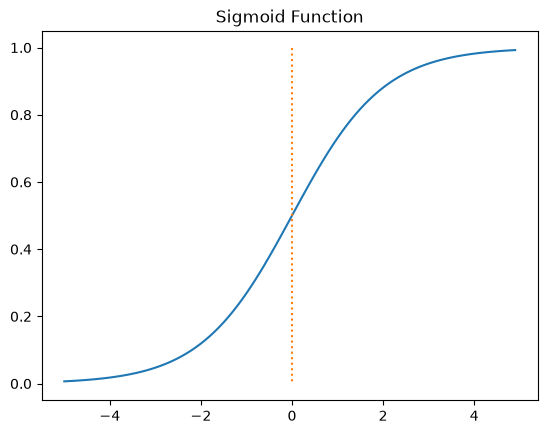

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))
    
x = np.arange(-5.0, 5.0, 0.1)
y = sigmoid(x)

plt.plot(x, y)
plt.plot([0, 0], [1.0, 0.0], ':')
plt.title('Sigmoid Function')
plt.show()

### 2. 하이퍼볼릭탄젠트
하이퍼볼릭 탄젠트(흔히 Tanh 함수라고 불림)는 비선형 활성화 함수 중 하나로, 입력 값을 -1에서 1 사이의 값으로 변환하는 함수입니다. 입력 값이 큰 양수일수록 1에 가까워지고, 큰 음수일수록 -1에 가까워집니다. 이 함수는 출력 범위가 대칭적이어서 Sigmoid 함수와 달리 출력이 0을 기준으로 분포되므로, 데이터가 양수와 음수로 분리되는 문제에서 더 적합합니다. 그러나 입력 값이 매우 크거나 작을 경우 기울기가 거의 0에 가까워지는 "기울기 소실" 문제가 발생할 수 있습니다. Tanh는 주로 출력 값의 분포를 중심에 맞추고 싶을 때 사용됩니다.

```
Tanh는 출력 범위가 -1 < Tanh(x) < 1 이고 중앙 부분에서는 괜찮지만 입력값의 절댓값이 커지면 역시 그래프가 평평해짐. 따라서 깊은 신경망에서는 gradient가 점점 작아질 수 있음
```

마찬가지로 기울기 소실 문제가 있어 최근에 잘 사용하진 않음

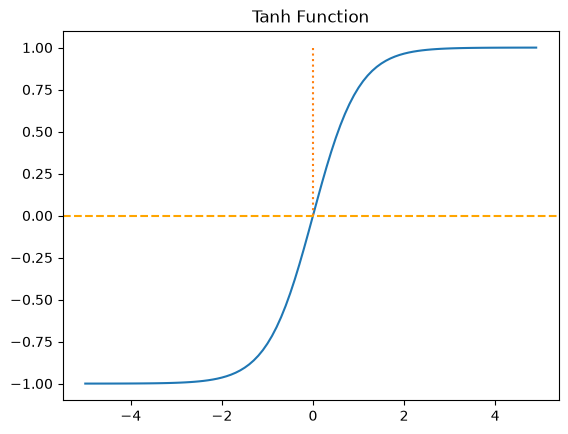

In [14]:
x = np.arange(-5.0, 5.0, 0.1)
y = np.tanh(x)

plt.plot(x, y)
plt.plot([0, 0], [1.0, 0.0], ':')
plt.axhline(y=0, color='orange', linestyle='--')
plt.title('Tanh Function')
plt.show()

### 3. 렐루
ReLU(Rectified Linear Unit)는 신경망에서 가장 널리 사용되는 비선형 활성화 함수 중 하나로, 입력 값이 0보다 크면 그대로 출력하고, 0 이하이면 0을 출력하는 함수입니다. 출력 값이 양수인 경우 기울기가 1로 일정하게 유지되므로 기울기 소실 문제를 완화할 수 있습니다. 이로 인해 학습이 빠르고 효율적이며, 깊은 신경망에서 성능이 뛰어난 것으로 알려져 있습니다. 그러나 ReLU는 입력 값이 0 이하일 때 기울기가 0이 되어 학습되지 않는 "죽은 ReLU" 문제가 발생할 수 있으며, 이를 보완하기 위해 Leaky ReLU와 같은 변형 함수들이 개발되었습니다.

```
ReLU의 양수 영역은 기울기가 1임
예) 출력 > *1 > *1 > *1 > 입력
기울기가 줄어들지 않음

"ReLU도 0이하는 기울기가 0임"
x > 0 ReLU(x) = 1 Gradient가 잘 통과
x < 0 ReLU(x) = 0 Gradient가 차단됨
특정 뉴런의 입력이 계속 음수라면 Gradient가 0이 되어 해당 뉴런의 weight가 제대로 업데이트 되지 않을 수 있음
그리고 계속 음수 영역에 머무르면 뉴런이 사실상 학습을 멈추게 됨 > 죽은 렐루 문제
```

> ReLU의 음수 영역을 완전히 0으로 만들지 말자라는 아이디어에서 나온 함수가 Leakey ReLU


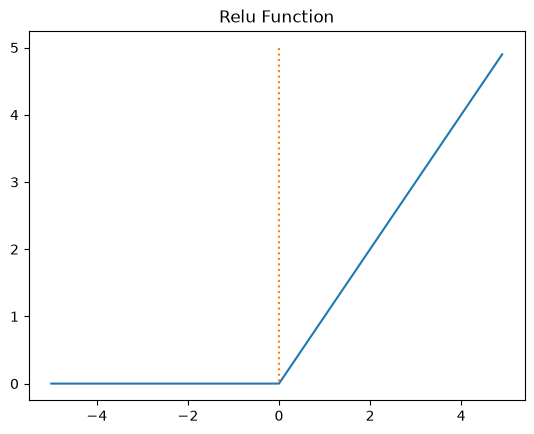

In [15]:
def relu(x):
    return np.maximum(0, x)

x = np.arange(-5.0, 5.0, 0.1)
y = relu(x)

plt.plot(x, y)
plt.plot([0, 0], [5.0, 0.0], ':')
plt.title('Relu Function')
plt.show()

![활성화함수](./images/활성화함수.png)